# Experiment 8: Artificial Neural Networks using Keras


## Task 1: Design and implement Artificial Neural Network architectures using Keras for classification tasks
*Suggested Dataset: Pima Indians Diabetes Dataset*


### Subtask 1.1: Data Acquisition, Imputation, and Feature Scaling
**Concept:** Import warnings suppression, load the raw Pima Indians dataset, handle missing value zeros using median imputation, standardize the features, and perform a stratified train-test split.


In [5]:
import warnings

In [6]:
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np

In [7]:
import pandas as pd

In [8]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import StandardScaler

In [9]:
from sklearn.impute import SimpleImputer

In [3]:
# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"


In [10]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [11]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [4]:
# Prevent copy warnings using an explicit copy
X_pima = pima_df[pima_cols[:-1]].copy()


In [12]:
y_pima = pima_df['Outcome']

In [13]:
# Mark invalid zeros as NaN placeholders for imputation
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [14]:
X_pima[cols_to_impute] = X_pima[cols_to_impute].replace(0, np.nan)

In [15]:
# Impute and standardize
imputer = SimpleImputer(strategy='median')

In [16]:
X_imputed = imputer.fit_transform(X_pima)

In [17]:
scaler = StandardScaler()

In [18]:
X_pima_scaled = scaler.fit_transform(X_imputed)

In [19]:
# Stratified train-test split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima_scaled, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [20]:
print("Preprocessed Pima dataset shapes:")
print(f"  Training set features: {X_train_p.shape} | Test set features: {X_test_p.shape}")


Preprocessed Pima dataset shapes:
  Training set features: (614, 8) | Test set features: (154, 8)


### Subtask 1.2: Designing Feedforward Neural Network Architectures
**Concept:** Design a baseline feedforward Artificial Neural Network (ANN) using Keras Sequential API, configuring hidden Dense layers with ReLU activations and a binary Sigmoid output node.


In [21]:
import tensorflow as tf

In [22]:
from tensorflow.keras.models import Sequential

In [23]:
from tensorflow.keras.layers import Dense

In [24]:
# Design baseline sequential model
ann_pima = Sequential([
    # Input layer + Hidden layer 1: 16 neurons with ReLU activation
    Dense(16, activation='relu', input_shape=(8,)),
    # Hidden layer 2: 8 neurons with ReLU activation
    Dense(8, activation='relu'),
    # Output layer: 1 neuron with Sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

In [25]:
print("Sequential ANN Architecture established:")
ann_pima.summary()

Sequential ANN Architecture established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

### Subtask 1.3: Compiling the Neural Network Model
**Concept:** Compile the sequential model by defining binary_crossentropy as the loss function, Adam as the optimizer, and accuracy as the primary evaluation metric.


In [26]:
# Compile the neural network model
ann_pima.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [27]:
print("Neural network model compiled successfully.")

Neural network model compiled successfully.


### Subtask 1.4: Fitting the Network with Validation Splits
**Concept:** Train the compiled network on the training set for 50 epochs using a batch size of 16 and a 20% validation split.


In [28]:
# Fit model and collect training metrics
history_pima = ann_pima.fit(
    X_train_p,
    y_train_p,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6375 - loss: 0.6521 - val_accuracy: 0.6260 - val_loss: 0.7011
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6538 - loss: 0.6022 - val_accuracy: 0.6423 - val_loss: 0.6429
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6660 - loss: 0.5666 - val_accuracy: 0.6585 - val_loss: 0.6046
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6640 - loss: 0.5419 - val_accuracy: 0.6911 - val_loss: 0.5763
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7108 - loss: 0.5213 - val_accuracy: 0.7073 - val_loss: 0.5507
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7189 - loss: 0.5037 - val_accuracy: 0.7317 - val_loss: 0.5348
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7495 - loss: 0.4904 - val_accuracy: 0.7317 - val_loss: 0.5173
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7699 - loss: 0.4797 - val_accuracy: 0.7642 - val_loss

In [29]:
print("\nModel training complete.")


Model training complete.


### Subtask 1.5: Evaluating Classifications on Held-out Test Data
**Concept:** Predict output probabilities on held-out test data, threshold them at 0.5, and evaluate predictions using accuracy, a confusion matrix, and a classification report.


In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [31]:
import seaborn as sns

In [32]:
import matplotlib.pyplot as plt

In [33]:
# Predict target probabilities
y_pred_probs = ann_pima.predict(X_test_p)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [34]:
# Threshold probabilities to binary classes (0 or 1)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

In [35]:
test_acc = accuracy_score(y_test_p, y_pred_classes)

In [36]:
print(f"ANN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test_p, y_pred_classes, target_names=['No Diabetes', 'Diabetes']))

ANN Holdout Test Accuracy: 71.43%

--- Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.76      0.82      0.79       100
    Diabetes       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



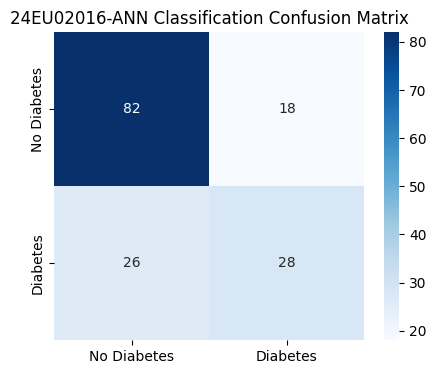

In [95]:
# Plot confusion matrix
cm_pima = confusion_matrix(y_test_p, y_pred_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("24EU02016-ANN Classification Confusion Matrix")
plt.show()

## Task 2: Train neural network models and analyze learning behavior using suitable evaluation measures
*Suggested Dataset: Sonar Dataset*


### Subtask 2.1: Standard Scaling and High-Dimensional Data Splitting
**Concept:** Import warnings suppression, load the Sonar dataset, map nominal class labels, standardize features, and perform a stratified split.


In [38]:
import warnings

In [39]:
warnings.filterwarnings("ignore")

In [40]:
import pandas as pd

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [44]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [45]:
sonar_columns = sonar_features + ['Class']

In [46]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [47]:
# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [48]:
X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']


In [49]:
# Scale features
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [50]:
# Split into train/test sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [51]:

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


### Subtask 2.2: Designing Deep Neural Networks with Dropout Regularization
**Concept:** Construct a deep multi-layer neural network using Keras and incorporate Dropout layers to prevent overfitting on high-dimensional continuous features.


In [52]:
from tensorflow.keras.models import Sequential

In [53]:
from tensorflow.keras.layers import Dense, Dropout

In [57]:
# Design regularized sequential network
ann_sonar = Sequential([
    # Input layer + Dense hidden layer 1
    Dense(64, activation='relu', input_shape=(60,)),
    Dropout(0.3), # Apply 30% dropout rate to mitigate co-adaptation
    # Dense hidden layer 2
    Dense(32, activation='relu'),
    Dropout(0.3), # Apply 30% dropout rate
    # Binary sigmoid output node
    Dense(1, activation='sigmoid')
])



In [58]:
print("Regularized Sonar ANN Architecture established:")
ann_sonar.summary()

Regularized Sonar ANN Architecture established:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

### Subtask 2.3: Compiling and Training the Sonar Network
**Concept:** Compile your model with the Adam optimizer, fit it on the Sonar training set for 80 epochs, and collect the training metrics.


In [59]:
# Compile the model
ann_sonar.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [60]:
# Fit model and collect training metrics
history_sonar = ann_sonar.fit(
    X_train_s,
    y_train_s,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.4741 - loss: 0.8574 - val_accuracy: 0.5862 - val_loss: 0.7161
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6034 - loss: 0.7052 - val_accuracy: 0.6552 - val_loss: 0.6591
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6121 - loss: 0.6666 - val_accuracy: 0.7241 - val_loss: 0.6253
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6466 - loss: 0.6147 - val_accuracy: 0.7586 - val_loss: 0.5995
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6983 - loss: 0.5764 - val_accuracy: 0.7586 - val_loss: 0.5757
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6897 - loss: 0.5655 - val_accuracy: 0.7241 - val_loss: 0.5541
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6810 - loss: 0.5648 - val_accuracy: 0.7586 - val_loss: 0.5389
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7328 - loss: 0.5086 - val_accuracy: 0.7586 - val_loss: 0.5157


In [61]:
print("\nModel training complete.")


Model training complete.


### Subtask 2.4: Plotting Loss and Accuracy Learning Curves
**Concept:** Plot the training versus validation loss and training versus validation accuracy curves across epochs to analyze model convergence and detect overfitting.


In [62]:
import matplotlib.pyplot as plt

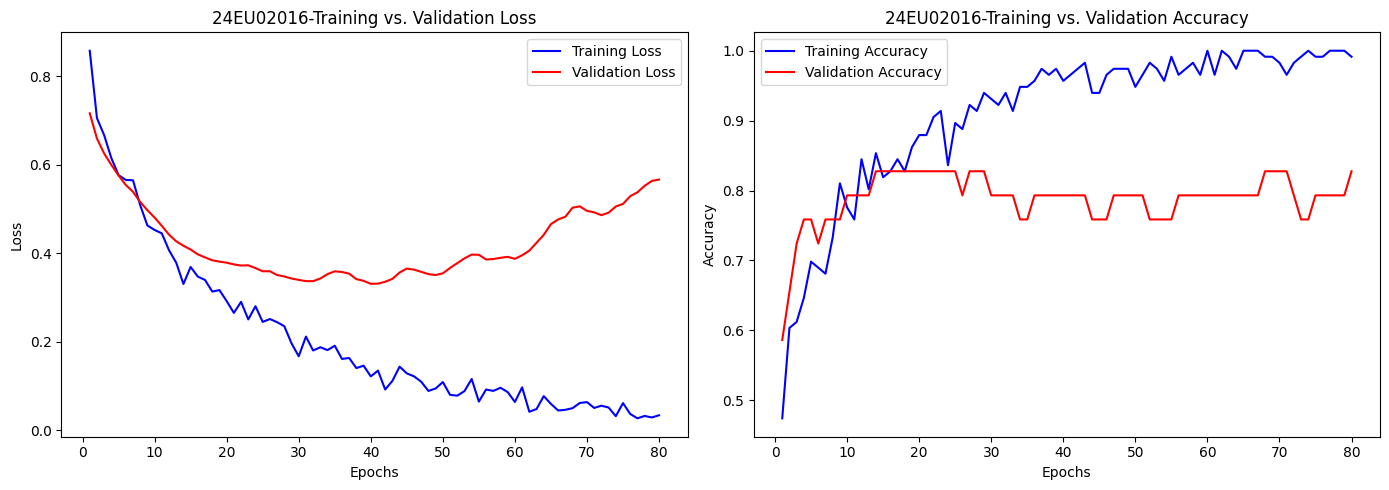

In [96]:
# Extract metrics from training history
train_loss = history_sonar.history['loss']
val_loss = history_sonar.history['val_loss']
train_acc = history_sonar.history['accuracy']
val_acc = history_sonar.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss, 'b-', label='Training Loss')
axes[0].plot(epochs_range, val_loss, 'r-', label='Validation Loss')
axes[0].set_title("24EU02016-Training vs. Validation Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot accuracy curves
axes[1].plot(epochs_range, train_acc, 'b-', label='Training Accuracy')
axes[1].plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
axes[1].set_title("24EU02016-Training vs. Validation Accuracy")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


### Subtask 2.5: Evaluating Classification Metrics and ROC-AUC Curves
**Concept:** Evaluate predictions on the test set and plot the Receiver Operating Characteristic (ROC) curve to calculate the Area Under the Curve (AUC).


In [68]:
from sklearn.metrics import classification_report, roc_curve, auc

In [69]:
import matplotlib.pyplot as plt

In [70]:
# Predict probabilities on test set
sonar_probs = ann_sonar.predict(X_test_s)[:, 0]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


In [71]:
sonar_preds = (sonar_probs >= 0.5).astype(int)

In [72]:
# Print classification report
print("--- Classification Report (Sonar Test Set) ---")
print(classification_report(y_test_s, sonar_preds, target_names=['Rock (0)', 'Mine (1)']))

--- Classification Report (Sonar Test Set) ---
              precision    recall  f1-score   support

    Rock (0)       0.84      0.90      0.87        29
    Mine (1)       0.91      0.85      0.88        34

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.88      0.87      0.87        63



In [73]:
# Compute ROC curve coordinates and AUC score
fpr, tpr, _ = roc_curve(y_test_s, sonar_probs)
roc_auc = auc(fpr, tpr)

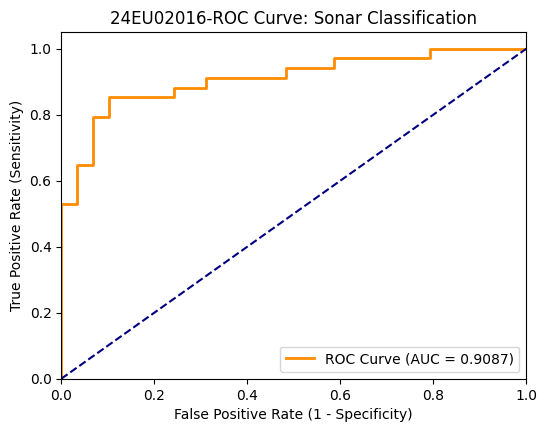

In [97]:
# Plot the ROC curve
plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("24EU02016-ROC Curve: Sonar Classification")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.show()

## Task 3: Perform hyperparameter optimization to improve neural network performance and generalization
*Continuous Optimization and Regularization on Pima Indians Dataset*


### Subtask 3.1: Building a Parameterized Network Builder Function
**Concept:** Construct a flexible, parameter-driven builder function that lets you compile an ANN model with different optimizer choices.


In [75]:
import tensorflow as tf

In [76]:
from tensorflow.keras.models import Sequential

In [77]:
from tensorflow.keras.layers import Dense

In [78]:
# Define parameterized builder function
def build_ann_model(optimizer_name='adam'):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(8,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer_name,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [79]:
print("Modular ANN model builder function established.")


Modular ANN model builder function established.


### Subtask 3.2: Tuning Convergence Speeds manually
**Concept:** Run a manual search loop across different optimizers (Adam, SGD, RMSprop) to compare training loss convergence.


In [80]:
optimizers = ['adam', 'sgd', 'rmsprop']
history_records = {}

In [81]:
print("--- Running Optimizer Search ---")
for opt in optimizers:
    print(f"Training network using: {opt}...")
    temp_model = build_ann_model(optimizer_name=opt)

    # Fit for 30 epochs
    hist = temp_model.fit(
        X_train_p,
        y_train_p,
        validation_split=0.2,
        epochs=30,
        batch_size=16,
        verbose=0
    )
    history_records[opt] = hist.history['loss']

--- Running Optimizer Search ---
Training network using: adam...
Training network using: sgd...
Training network using: rmsprop...


In [82]:
print("Tuning loop complete.")

Tuning loop complete.


### Subtask 3.3: Comparing Optimizer Loss Trajectories
**Concept:** Plot the training loss trajectories across your selected optimizers to evaluate and select the fastest converging solver.


In [83]:
import matplotlib.pyplot as plt

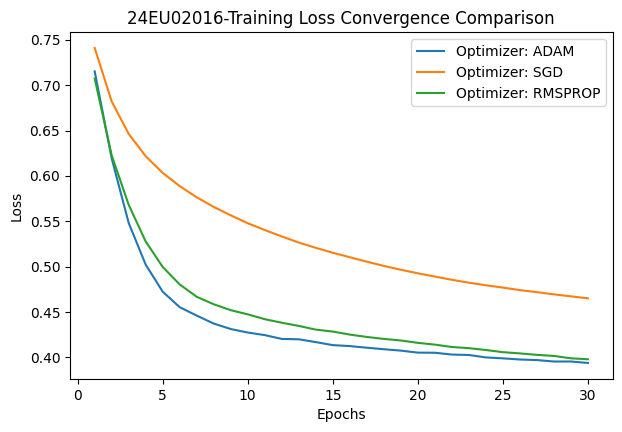

In [98]:
# Plot optimizer training loss profiles
plt.figure(figsize=(7, 4.5))
for opt in optimizers:
    plt.plot(range(1, 31), history_records[opt], label=f"Optimizer: {opt.upper()}")

plt.title("24EU02016-Training Loss Convergence Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


### Subtask 3.4: Implementing Early Stopping Regularization
**Concept:** Set up an EarlyStopping callback to automatically halt training and restore the best weights when the validation loss stops improving.


In [85]:
from tensorflow.keras.callbacks import EarlyStopping

In [86]:
# Configure EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [87]:

# Build model with the optimal optimizer found
tuned_model = build_ann_model(optimizer_name='adam')

In [88]:
print("Training model with Early Stopping...")

Training model with Early Stopping...


In [89]:
# Fit model for up to 100 epochs
history_tuned = tuned_model.fit(
    X_train_p,
    y_train_p,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6395 - loss: 0.6537 - val_accuracy: 0.6504 - val_loss: 0.6090
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6965 - loss: 0.5724 - val_accuracy: 0.6992 - val_loss: 0.5414
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7251 - loss: 0.5235 - val_accuracy: 0.7154 - val_loss: 0.5023
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7556 - loss: 0.4938 - val_accuracy: 0.7561 - val_loss: 0.4779
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7719 - loss: 0.4756 - val_accuracy: 0.7724 - val_loss: 0.4625
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7699 - loss: 0.4642 - val_accuracy: 0.7724 - val_loss: 0.4504
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7821 - loss: 0.4546 - val_accuracy: 0.7724 - val_loss: 0.4435
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7902 - loss: 0.4473 - val_accuracy: 0.7724

### Subtask 3.5: Evaluating the Tuned, Regularized Model
**Concept:** Compare the final test accuracy of the tuned, early-stopped model against the baseline model trained with fixed epochs in Task 1.


In [90]:
from sklearn.metrics import accuracy_score

In [91]:
# Evaluate baseline model from Task 1
baseline_accuracy = ann_pima.evaluate(X_test_p, y_test_p, verbose=0)[1]

In [92]:
# Evaluate the tuned, early-stopped model
tuned_accuracy = tuned_model.evaluate(X_test_p, y_test_p, verbose=0)[1]

In [93]:
comparison_df = pd.DataFrame({
    'Model Configuration': ['Baseline ANN (Fixed 50 Epochs)', 'Tuned ANN (with Early Stopping)'],
    'Test Accuracy (%)': [baseline_accuracy * 100, tuned_accuracy * 100],
    'Epochs Trained': [50, len(history_tuned.history['loss'])]
})

In [94]:
print("--- Final Performance Comparison ---")
print(comparison_df.to_string(index=False))


--- Final Performance Comparison ---
            Model Configuration  Test Accuracy (%)  Epochs Trained
 Baseline ANN (Fixed 50 Epochs)          71.428573              50
Tuned ANN (with Early Stopping)          73.376626              37
